<ipython-input-1-f62d229e444c>:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


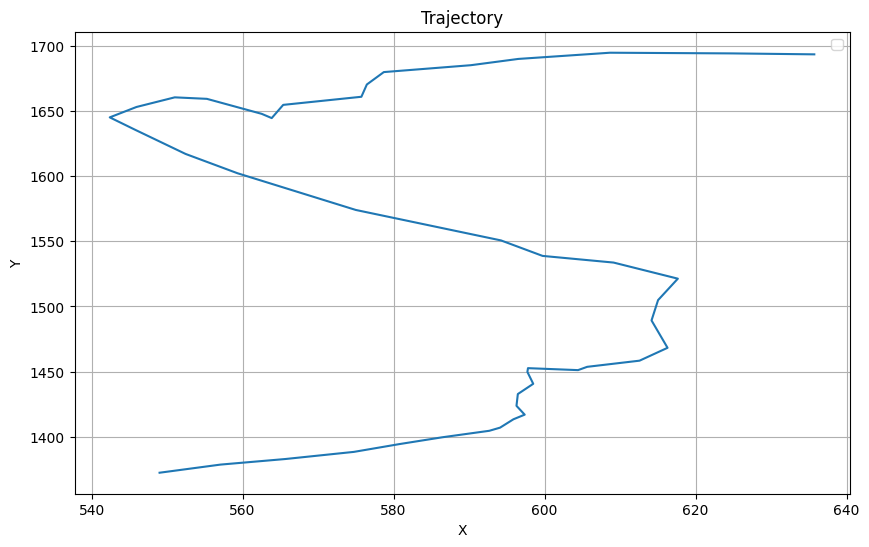

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/Book1.xlsx'

def plot_xlsx_columns(file_path):
    # Load the Excel file
    xls = pd.ExcelFile(file_path)
    plt.figure(figsize=(10, 6))

    for sheet_name in xls.sheet_names:
        # Read each sheet into a DataFrame
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        # Ensure there are at least 6 columns
        if df.shape[1] < 6:
            print(f"Skipping sheet '{sheet_name}' as it has less than 6 columns.")
            continue

        # Extract x and y columns (0-based index, so 5th and 6th columns are index 4 and 5)
        x = df.iloc[:, 4]
        y = df.iloc[:, 5]

        # Plot the data
        #plt.plot(x, y, label=sheet_name)
        #plt.figure(figsize=(6, 6))
        plt.plot(x, y)

    plt.xlabel("X") #column 5
    plt.ylabel("Y") #column 6
    plt.title("Trajectory")
    plt.legend()
    plt.grid()
    plt.show()

# Example usage:
plot_xlsx_columns(file_path)


Skipping sheet 'Sheet93' as it has less than 6 columns.
Skipping sheet 'Sheet100' as it has less than 6 columns.


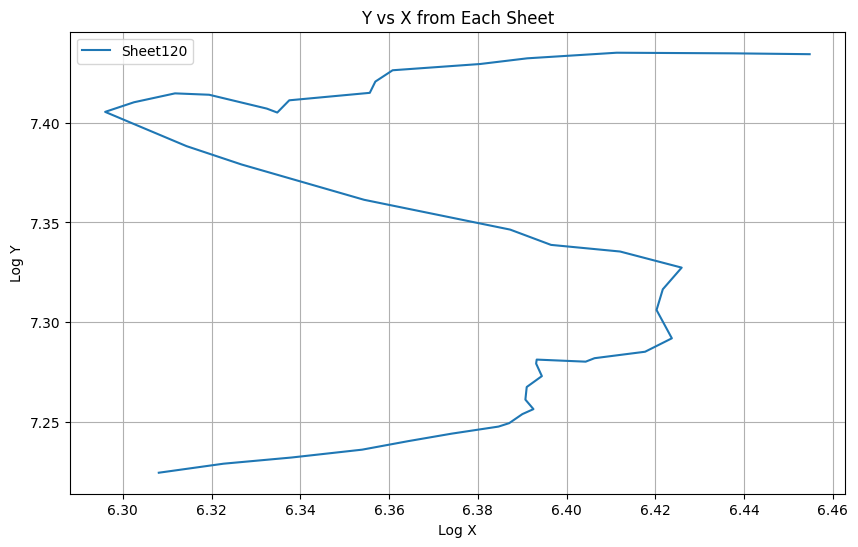

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/empty_core­_raw­_data.xlsx'

def plot_xlsx_columns(file_path):
    # Load the Excel file
    xls = pd.ExcelFile(file_path)
    plt.figure(figsize=(10, 6))

    for sheet_name in xls.sheet_names:
        # Read each sheet into a DataFrame
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        # Ensure there are at least 6 columns
        if df.shape[1] < 6:
            print(f"Skipping sheet '{sheet_name}' as it has less than 6 columns.")
            continue

        # Extract x and y columns (0-based index, so 5th and 6th columns are index 4 and 5)
        x = df.iloc[:, 4]
        y = df.iloc[:, 5]


    logx = np.log(x)
    logy = np.log(y)

        # Plot the data
    plt.plot(logx, logy, label=sheet_name)


    plt.xlabel("Log X") #column 5
    plt.ylabel("Log Y") #column 6
    plt.title("Y vs X from Each Sheet")
    plt.legend()
    plt.grid()
    plt.show()

# Example usage:
plot_xlsx_columns(file_path)

#df.to_csv('your_file_name. csv', index=False)


<ipython-input-7-93e961916dd7>:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


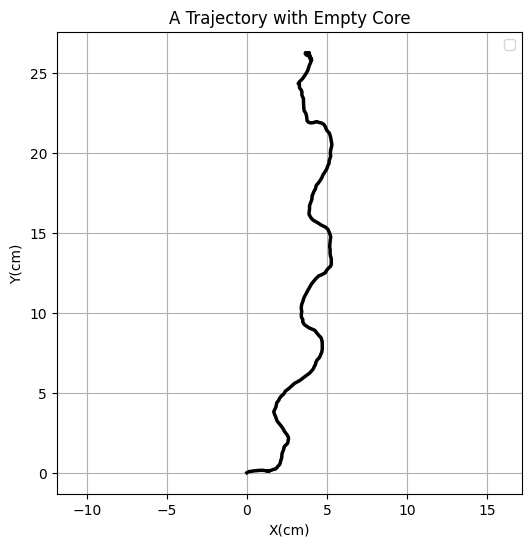

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

file_path = '/content/Book1.xlsx'

def compute_cumulative_distance(x, y):
    return np.cumsum(np.sqrt(np.diff(x, prepend=x[0])**2 + np.diff(y, prepend=y[0])**2))

def plot_debug_average_trajectory(file_path, num_points=500, use_median=False, align_start=True):
    xls = pd.ExcelFile(file_path)
    x_list = []
    y_list = []

    sheet_names = xls.sheet_names
    colors = cm.viridis(np.linspace(0, 1, len(sheet_names)))

    for i, sheet_name in enumerate(sheet_names):
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        if df.shape[1] < 6:
            print(f"Skipping sheet '{sheet_name}' as it has less than 6 columns.")
            continue

        x = df.iloc[:, 4].dropna().values * 0.01899
        y = df.iloc[:, 5].dropna().values * 0.01911

        if len(x) < 2 or len(y) < 2:
            print(f"Skipping sheet '{sheet_name}' due to insufficient points.")
            continue

        if align_start:
            x -= x[0]
            y -= y[0]

        dist = compute_cumulative_distance(x, y)
        dist -= dist[0]
        if dist[-1] == 0:
            print(f"Skipping sheet '{sheet_name}' due to zero path length.")
            continue
        dist /= dist[-1]

        common_dist = np.linspace(0, 1, num=num_points)
        try:
            x_interp = np.interp(common_dist, dist, x)
            y_interp = np.interp(common_dist, dist, y)
        except Exception as e:
            print(f"Interpolation failed for sheet '{sheet_name}': {e}")
            continue

        x_list.append(x_interp)
        y_list.append(y_interp)

    if not x_list:
        print("🚫 No usable data.")
        return

    x_array = np.vstack(x_list)
    y_array = np.vstack(y_list)

    if use_median:
        x_avg = np.median(x_array, axis=0)
        y_avg = np.median(y_array, axis=0)
        label = "Median Path"
    else:
        x_avg = np.mean(x_array, axis=0)
        y_avg = np.mean(y_array, axis=0)
        label = "Mean Path"

    # Plot
    plt.figure(figsize=(6, 6))
    for i in range(len(x_list)):
        plt.plot(x_array[i], y_array[i], color=colors[i], alpha=0.4)

    plt.plot(x_avg, y_avg, color='black', linewidth=2.5, label = label)
    plt.xlabel("X(cm)")
    plt.ylabel("Y(cm)")
    plt.title("A Trajectory with Empty Core")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

# Run it
plot_debug_average_trajectory(file_path, use_median=False, align_start=True)


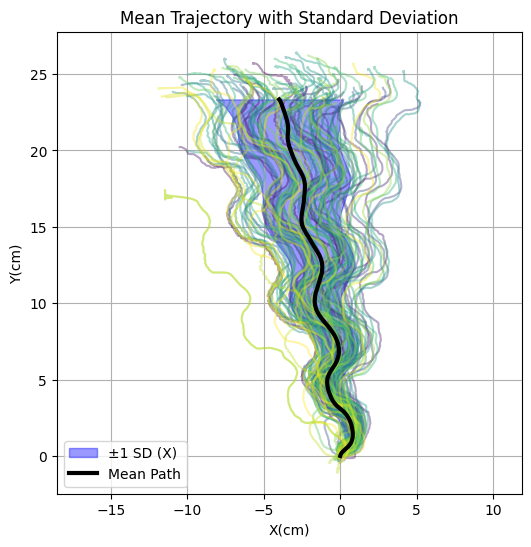

In [ ]:
#Mean Trajectory with Standard Deviation

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

file_path = '/content/slime_core.xlsx'

def compute_cumulative_distance(x, y):
    return np.cumsum(np.sqrt(np.diff(x, prepend=x[0])**2 + np.diff(y, prepend=y[0])**2))

def plot_mean_with_std_band(file_path, num_points=500, align_start=True):
    xls = pd.ExcelFile(file_path)
    x_list = []
    y_list = []

    sheet_names = xls.sheet_names
    colors = cm.viridis(np.linspace(0, 1, len(sheet_names)))

    for i, sheet_name in enumerate(sheet_names):
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        if df.shape[1] < 6:
            continue

        x = df.iloc[:, 4].dropna().values * 0.01899
        y = df.iloc[:, 5].dropna().values * 0.01911

        if len(x) < 2 or len(y) < 2:
            continue

        if align_start:
            x -= x[0]
            y -= y[0]

        dist = compute_cumulative_distance(x, y)
        dist -= dist[0]
        if dist[-1] == 0:
            continue
        dist /= dist[-1]

        common_dist = np.linspace(0, 1, num=num_points)
        try:
            x_interp = np.interp(common_dist, dist, x)
            y_interp = np.interp(common_dist, dist, y)
        except:
            continue

        x_list.append(x_interp)
        y_list.append(y_interp)

    if not x_list:
        print("🚫 No usable data.")
        return

    x_array = np.vstack(x_list)
    y_array = np.vstack(y_list)

    # Mean path
    x_avg = np.mean(x_array, axis=0)
    y_avg = np.mean(y_array, axis=0)

    # Standard deviation at each point
    x_std = np.std(x_array, axis=0)
    y_std = np.std(y_array, axis=0)

    # Plot
    plt.figure(figsize=(6, 6))
    for i in range(len(x_list)):
        plt.plot(x_array[i], y_array[i], color=colors[i], alpha=0.4)

    # SD bands with strong colors
    plt.fill_betweenx(y_avg, x_avg - x_std, x_avg + x_std,
                      color='blue', alpha=0.4, label='±1 SD (X)')
    #plt.fill_between(x_avg, y_avg - y_std, y_avg + y_std,
                     #color='red', alpha=0.8, label='±1 SD (Y)')

    # Mean path
    plt.plot(x_avg, y_avg, color='black', linewidth=3, label="Mean Path")

    plt.xlabel("X(cm)")
    plt.ylabel("Y(cm)")
    plt.title("Mean Trajectory with Standard Deviation")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

# Run it
plot_mean_with_std_band(file_path, align_start=True)


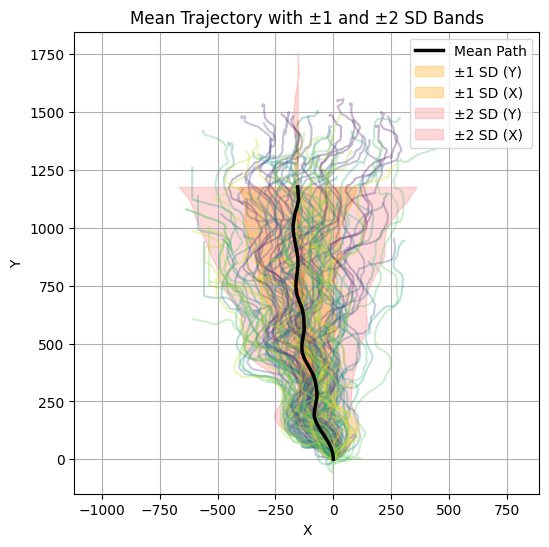

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

file_path = '/content/empty_core­_raw­_data.xlsx'

def compute_cumulative_distance(x, y):
    return np.cumsum(np.sqrt(np.diff(x, prepend=x[0])**2 + np.diff(y, prepend=y[0])**2))

def plot_mean_with_std_band(file_path, num_points=500, align_start=True):
    xls = pd.ExcelFile(file_path)
    x_list = []
    y_list = []

    sheet_names = xls.sheet_names
    colors = cm.viridis(np.linspace(0, 1, len(sheet_names)))

    for i, sheet_name in enumerate(sheet_names):
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        if df.shape[1] < 6:
            continue

        x = df.iloc[:, 4].dropna().values
        y = df.iloc[:, 5].dropna().values

        if len(x) < 2 or len(y) < 2:
            continue

        if align_start:
            x -= x[0]
            y -= y[0]

        dist = compute_cumulative_distance(x, y)
        dist -= dist[0]
        if dist[-1] == 0:
            continue
        dist /= dist[-1]

        common_dist = np.linspace(0, 1, num=num_points)
        try:
            x_interp = np.interp(common_dist, dist, x)
            y_interp = np.interp(common_dist, dist, y)
        except:
            continue

        x_list.append(x_interp)
        y_list.append(y_interp)

    if not x_list:
        print("🚫 No usable data.")
        return

    x_array = np.vstack(x_list)
    y_array = np.vstack(y_list)

    # Mean path
    x_avg = np.mean(x_array, axis=0)
    y_avg = np.mean(y_array, axis=0)

    # Standard deviation at each point
    x_std = np.std(x_array, axis=0)
    y_std = np.std(y_array, axis=0)

    # Plot
    plt.figure(figsize=(6, 6))
    for i in range(len(x_list)):
        plt.plot(x_array[i], y_array[i], color=colors[i], alpha=0.3)

    # Mean path
    plt.plot(x_avg, y_avg, color='black', linewidth=2.5, label="Mean Path")

    # ±1 SD band
    plt.fill_between(x_avg, y_avg - y_std, y_avg + y_std, color='orange', alpha=0.3, label='±1 SD (Y)')
    plt.fill_betweenx(y_avg, x_avg - x_std, x_avg + x_std, color='orange', alpha=0.3, label='±1 SD (X)')

    # ±2 SD band
    plt.fill_between(x_avg, y_avg - 2*y_std, y_avg + 2*y_std, color='red', alpha=0.15, label='±2 SD (Y)')
    plt.fill_betweenx(y_avg, x_avg - 2*x_std, x_avg + 2*x_std, color='red', alpha=0.15, label='±2 SD (X)')

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Mean Trajectory with ±1 and ±2 SD Bands")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

# Run it
plot_mean_with_std_band(file_path, align_start=True)


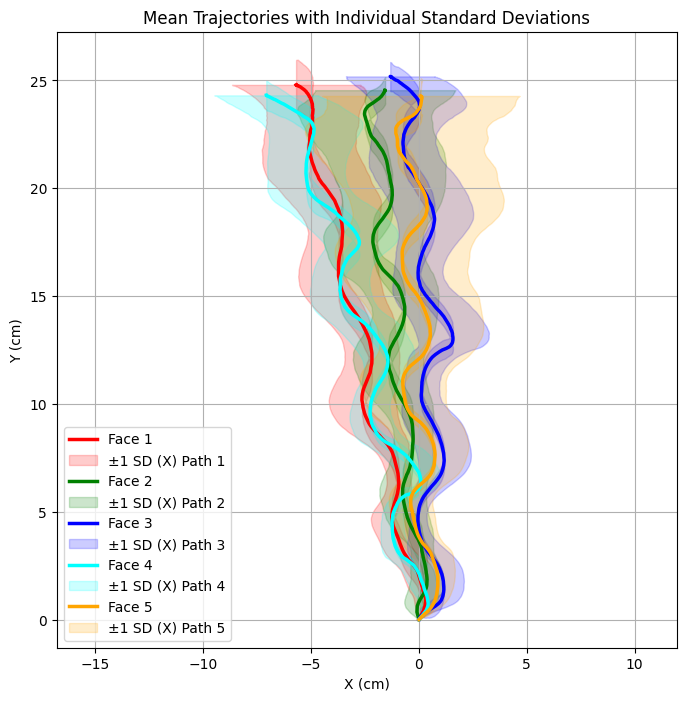

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

def compute_cumulative_distance(x, y):
    return np.cumsum(np.sqrt(np.diff(x, prepend=x[0])**2 + np.diff(y, prepend=y[0])**2))

def process_file(file_path, num_points=500, align_start=True):
    xls = pd.ExcelFile(file_path)
    x_list = []
    y_list = []

    sheet_names = xls.sheet_names

    for sheet_name in sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        if df.shape[1] < 6:
            continue

        x = df.iloc[:, 4].dropna().values * 0.01899
        y = df.iloc[:, 5].dropna().values * 0.01911

        if len(x) < 2 or len(y) < 2:
            continue

        if align_start:
            x -= x[0]
            y -= y[0]

        dist = compute_cumulative_distance(x, y)
        dist -= dist[0]
        if dist[-1] == 0:
            continue
        dist /= dist[-1]

        common_dist = np.linspace(0, 1, num=num_points)
        try:
            x_interp = np.interp(common_dist, dist, x)
            y_interp = np.interp(common_dist, dist, y)
        except:
            continue

        x_list.append(x_interp)
        y_list.append(y_interp)

    if not x_list:
        return None, None, None, None

    x_array = np.vstack(x_list)
    y_array = np.vstack(y_list)

    x_avg = np.mean(x_array, axis=0)
    y_avg = np.mean(y_array, axis=0)
    x_std = np.std(x_array, axis=0)
    y_std = np.std(y_array, axis=0)

    return x_avg, y_avg, x_std, y_std

def plot_mean_with_std_of_means(file_paths, num_points=500, align_start=True):
    plt.figure(figsize=(8, 8))
    path_colors = ['red', 'green', 'blue', 'cyan', 'orange']

    for i, file_path in enumerate(file_paths):
        x_avg, y_avg, x_std, y_std = process_file(file_path, num_points, align_start)
        if x_avg is None:
            print(f"⚠️ Skipping {file_path}: No usable data.")
            continue

        color = path_colors[i % len(path_colors)]

        # Plot the individual mean path
        plt.plot(x_avg, y_avg, color=color, linewidth=2.5, label=f"Face {i+1}")

        # Standard deviation band for each individual path
        plt.fill_between(x_avg, y_avg - y_std, y_avg + y_std, color=color, alpha=0.2, label=f'±1 SD (X) Path {i+1}')
        plt.fill_betweenx(y_avg, x_avg - x_std, x_avg + x_std, color=color, alpha=0.2)

    plt.xlabel("X (cm)")
    plt.ylabel("Y (cm)")
    plt.title("Mean Trajectories with Individual Standard Deviations")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage
file_paths = [
    '/content/face_ch_1.xlsx',
    '/content/face_ch_2.xlsx',
    '/content/face_ch_3.xlsx',
    '/content/face_ch_4.xlsx',
    '/content/face_ch_5.xlsx'
]

plot_mean_with_std_of_means(file_paths, align_start=True)


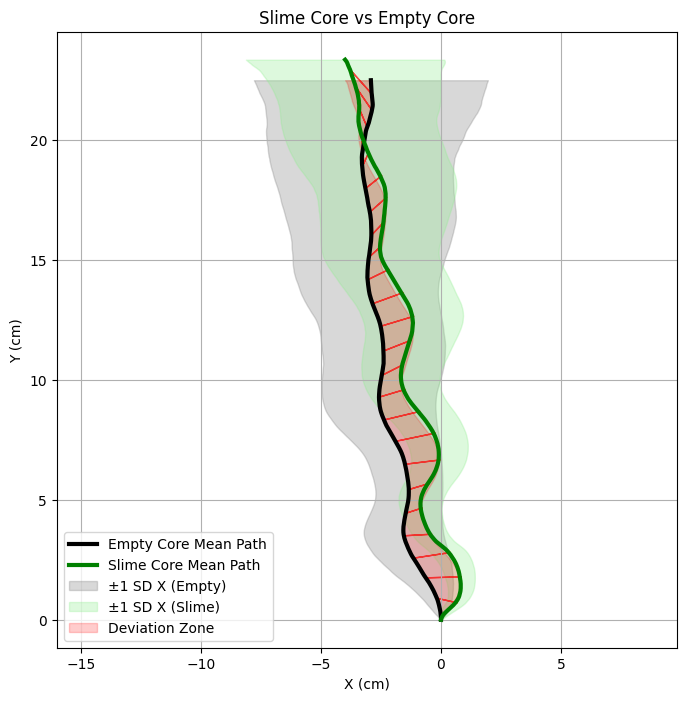

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def compute_cumulative_distance(x, y):
    return np.cumsum(np.sqrt(np.diff(x, prepend=x[0])**2 + np.diff(y, prepend=y[0])**2))

def process_file(file_path, num_points=500, align_start=True):
    xls = pd.ExcelFile(file_path)
    x_list = []
    y_list = []

    for sheet_name in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        if df.shape[1] < 6:
            continue

        x = df.iloc[:, 4].dropna().values * 0.01899
        y = df.iloc[:, 5].dropna().values * 0.01911

        if len(x) < 2 or len(y) < 2:
            continue

        if align_start:
            x -= x[0]
            y -= y[0]

        dist = compute_cumulative_distance(x, y)
        dist -= dist[0]
        if dist[-1] == 0:
            continue
        dist /= dist[-1]

        common_dist = np.linspace(0, 1, num=num_points)
        try:
            x_interp = np.interp(common_dist, dist, x)
            y_interp = np.interp(common_dist, dist, y)
        except:
            continue

        x_list.append(x_interp)
        y_list.append(y_interp)

    if not x_list:
        return None, None, None

    x_array = np.vstack(x_list)
    y_array = np.vstack(y_list)

    x_avg = np.mean(x_array, axis=0)
    y_avg = np.mean(y_array, axis=0)
    x_std = np.std(x_array, axis=0)

    return x_avg, y_avg, x_std

def plot_comparison_with_deviation(empty_core_file, slime_core_file, num_points=500, align_start=True):
    empty_x, empty_y, empty_x_std = process_file(empty_core_file, num_points, align_start)
    slime_x, slime_y, slime_x_std = process_file(slime_core_file, num_points, align_start)

    if empty_x is None or slime_x is None:
        print("🚫 One or both files have no usable data.")
        return

    deviation_x = slime_x - empty_x
    deviation_y = slime_y - empty_y
    deviation_mag = np.sqrt(deviation_x**2 + deviation_y**2)

    plt.figure(figsize=(8, 8))

    # Plot the mean paths
    plt.plot(empty_x, empty_y, color='black', linewidth=3, label="Empty Core Mean Path")
    plt.plot(slime_x, slime_y, color='green', linewidth=3, label="Slime Core Mean Path")

    # Plot standard deviation bands (X-direction only)
    plt.fill_betweenx(empty_y, empty_x - empty_x_std, empty_x + empty_x_std, color='gray', alpha=0.3, label='±1 SD X (Empty)')
    plt.fill_betweenx(slime_y, slime_x - slime_x_std, slime_x + slime_x_std, color='lightgreen', alpha=0.3, label='±1 SD X (Slime)')

    # Deviation arrows
    for i in range(0, len(empty_x), 20):
        plt.arrow(empty_x[i], empty_y[i], deviation_x[i], deviation_y[i],
                  head_width=0.05, head_length=0.08, fc='red', ec='red', alpha=0.7)

    # Deviation zone (shaded)
    plt.fill_betweenx(empty_y, empty_x, slime_x, color='red', alpha=0.2, label="Deviation Zone")

    plt.xlabel("X (cm)")
    plt.ylabel("Y (cm)")
    plt.title("Slime Core vs Empty Core")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage
empty_core_file = '/content/empty_core­_raw­_data.xlsx'
slime_core_file = '/content/slime_core.xlsx'

plot_comparison_with_deviation(empty_core_file, slime_core_file, align_start=True)


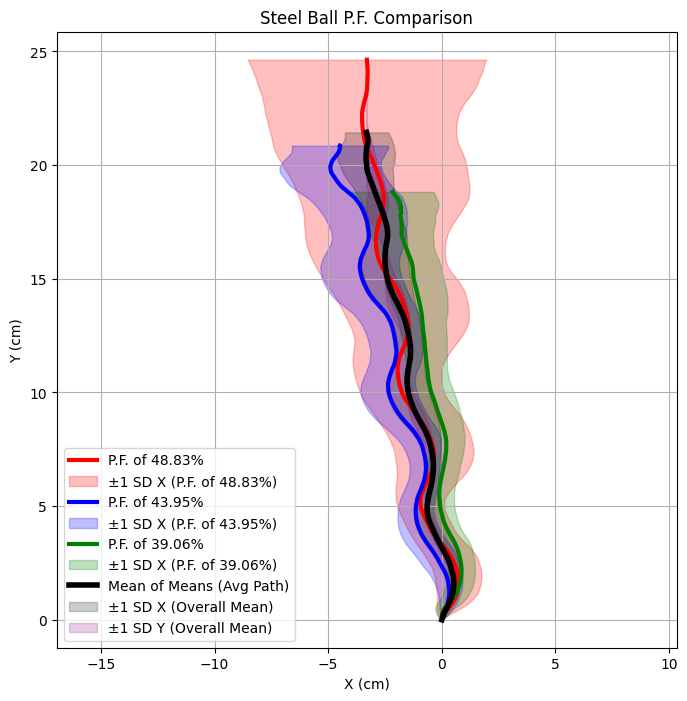

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

def compute_cumulative_distance(x, y):
    return np.cumsum(np.sqrt(np.diff(x, prepend=x[0])**2 + np.diff(y, prepend=y[0])**2))

def process_file(file_path, num_points=500, align_start=True):
    xls = pd.ExcelFile(file_path)
    x_list = []
    y_list = []

    sheet_names = xls.sheet_names

    for sheet_name in sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        if df.shape[1] < 6:
            continue

        x = df.iloc[:, 4].dropna().values * 0.01899
        y = df.iloc[:, 5].dropna().values * 0.01911

        if len(x) < 2 or len(y) < 2:
            continue

        if align_start:
            x -= x[0]
            y -= y[0]

        dist = compute_cumulative_distance(x, y)
        dist -= dist[0]
        if dist[-1] == 0:
            continue
        dist /= dist[-1]

        common_dist = np.linspace(0, 1, num=num_points)
        try:
            x_interp = np.interp(common_dist, dist, x)
            y_interp = np.interp(common_dist, dist, y)
        except:
            continue

        x_list.append(x_interp)
        y_list.append(y_interp)

    if not x_list:
        return None, None, None

    x_array = np.vstack(x_list)
    y_array = np.vstack(y_list)

    x_avg = np.mean(x_array, axis=0)
    y_avg = np.mean(y_array, axis=0)
    x_std = np.std(x_array, axis=0)

    return x_avg, y_avg, x_std

def plot_mean_with_std_of_means(file_paths, num_points=500, align_start=True):
    plt.figure(figsize=(8, 8))
    colors = cm.viridis(np.linspace(0, 1, len(file_paths)))

    all_x_means = []
    all_y_means = []

    labels = ['P.F. of 48.83%', 'P.F. of 43.95%', 'P.F. of 39.06%']

    for i, file_path in enumerate(file_paths):
        x_avg, y_avg, x_std = process_file(file_path, num_points, align_start)
        if x_avg is None:
            print(f"⚠️ Skipping {file_path}: No usable data.")
            continue

        all_x_means.append(x_avg)
        all_y_means.append(y_avg)

        label = labels[i] if i < len(labels) else f"Mean Path {i+1}"
        color = ['red', 'blue', 'green'][i] if i < 3 else 'gray'

        plt.plot(x_avg, y_avg, color=color, linewidth=3, label=label)
        plt.fill_betweenx(y_avg, x_avg - x_std, x_avg + x_std,
                          color=color, alpha=0.25, label=f'±1 SD X ({label})')

    if not all_x_means:
        print("🚫 No usable data.")
        return

    # Mean of means + overall SD shading
    all_x_means = np.vstack(all_x_means)
    all_y_means = np.vstack(all_y_means)

    x_mean_of_means = np.mean(all_x_means, axis=0)
    y_mean_of_means = np.mean(all_y_means, axis=0)
    x_std_of_means = np.std(all_x_means, axis=0)
    y_std_of_means = np.std(all_y_means, axis=0)

    plt.plot(x_mean_of_means, y_mean_of_means, color='black', linewidth=4, label="Mean of Means (Avg Path)")
    plt.fill_betweenx(y_mean_of_means, x_mean_of_means - x_std_of_means, x_mean_of_means + x_std_of_means,
                      color='black', alpha=0.2, label='±1 SD X (Overall Mean)')
    plt.fill_between(x_mean_of_means, y_mean_of_means - y_std_of_means, y_mean_of_means + y_std_of_means,
                     color='purple', alpha=0.2, label='±1 SD Y (Overall Mean)')

    plt.xlabel("X (cm)")
    plt.ylabel("Y (cm)")
    plt.title("Steel Ball P.F. Comparison")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage
file_paths = [
    '/content/steel_core_48.83.xlsx',
    '/content/steel_core_43.95.xlsx',
    '/content/steel_core_39.06.xlsx',
]

plot_mean_with_std_of_means(file_paths, align_start=True)


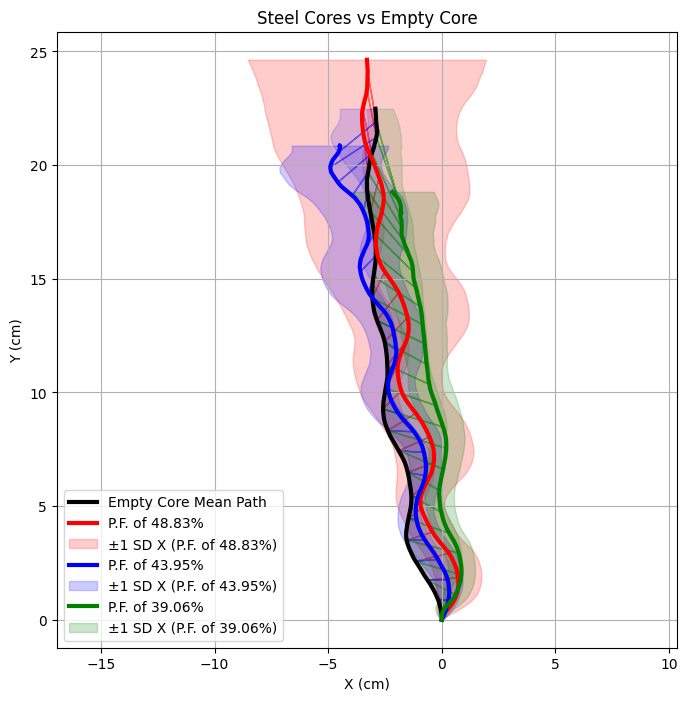

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def compute_cumulative_distance(x, y):
    return np.cumsum(np.sqrt(np.diff(x, prepend=x[0])**2 + np.diff(y, prepend=y[0])**2))

def process_file(file_path, num_points=500, align_start=True):
    xls = pd.ExcelFile(file_path)
    x_list = []
    y_list = []

    for sheet_name in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        if df.shape[1] < 6:
            continue

        x = df.iloc[:, 4].dropna().values * 0.01899
        y = df.iloc[:, 5].dropna().values * 0.01911

        if len(x) < 2 or len(y) < 2:
            continue

        if align_start:
            x -= x[0]
            y -= y[0]

        dist = compute_cumulative_distance(x, y)
        dist -= dist[0]
        if dist[-1] == 0:
            continue
        dist /= dist[-1]

        common_dist = np.linspace(0, 1, num=num_points)
        try:
            x_interp = np.interp(common_dist, dist, x)
            y_interp = np.interp(common_dist, dist, y)
        except:
            continue

        x_list.append(x_interp)
        y_list.append(y_interp)

    if not x_list:
        return None, None, None

    x_array = np.vstack(x_list)
    y_array = np.vstack(y_list)

    x_avg = np.mean(x_array, axis=0)
    y_avg = np.mean(y_array, axis=0)
    x_std = np.std(x_array, axis=0)

    return x_avg, y_avg, x_std

def plot_multiple_deviations(empty_core_file, steel_core_files, labels, num_points=500, align_start=True):
    empty_x, empty_y, _ = process_file(empty_core_file, num_points, align_start)

    if empty_x is None:
        print("🚫 Empty core file has no usable data.")
        return

    colors = ['red', 'blue', 'green']
    plt.figure(figsize=(8, 8))

    # Plot empty core path
    plt.plot(empty_x, empty_y, color='black', linewidth=3, label='Empty Core Mean Path')

    # Plot each steel core path and deviation
    for i, (file_path, label) in enumerate(zip(steel_core_files, labels)):
        steel_x, steel_y, steel_x_std = process_file(file_path, num_points, align_start)
        if steel_x is None:
            print(f"⚠️ Skipping {file_path}: No usable data.")
            continue

        deviation_x = steel_x - empty_x
        deviation_y = steel_y - empty_y
        deviation_mag = np.sqrt(deviation_x**2 + deviation_y**2)

        plt.plot(steel_x, steel_y, color=colors[i % len(colors)], linewidth=3, label=label)

        # Deviation arrows
        for j in range(0, len(empty_x), 20):
            plt.arrow(empty_x[j], empty_y[j], deviation_x[j], deviation_y[j],
                      head_width=0.05, head_length=0.08, fc=colors[i], ec=colors[i], alpha=0.5)

        # Shaded deviation area
        plt.fill_betweenx(empty_y, empty_x, steel_x, color=colors[i % len(colors)], alpha=0.15)

        # ±1 SD X band for steel core path
        plt.fill_betweenx(steel_y, steel_x - steel_x_std, steel_x + steel_x_std,
                          color=colors[i], alpha=0.2, label=f'±1 SD X ({label})')

    plt.xlabel("X (cm)")
    plt.ylabel("Y (cm)")
    plt.title("Steel Cores vs Empty Core")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage
empty_core_file = '/content/empty_core­_raw­_data.xlsx'

steel_core_files = [
    '/content/steel_core_48.83.xlsx',
    '/content/steel_core_43.95.xlsx',
    '/content/steel_core_39.06.xlsx'
]

labels = [
    'P.F. of 48.83%',
    'P.F. of 43.95%',
    'P.F. of 39.06%'
]

plot_multiple_deviations(empty_core_file, steel_core_files, labels, align_start=True)
